<a href="https://colab.research.google.com/github/Jose-guerra2002/data_mining/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd

In [20]:
url = "https://raw.githubusercontent.com/Jose-guerra2002/data_mining/refs/heads/main/Prestige_modificado.csv"

In [21]:
url = "https://raw.githubusercontent.com/Jose-guerra2002/data_mining/refs/heads/main/Prestige_modificado.csv"
df = pd.read_csv(url, sep=';')
print(df.columns.tolist())

['occupation', 'education', 'income', 'women', 'prestige', 'census', 'type_num']


In [22]:
print(df.shape)
print(df.head())

(102, 7)
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [5]:
# Mostrar las primeras filas del dataset
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [6]:
# Validar cantidad de registros y columnas
filas, columnas = df.shape
print(f"El dataset tiene {filas} registros y {columnas} columnas.")

El dataset tiene 102 registros y 7 columnas.


In [7]:
# Revisar nombres de columnas y tipos de datos
print("Información del dataset:")
print(df.info())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None


In [8]:
# Identificar valores nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

Valores nulos por columna:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Registros duplicados: 0


In [9]:
# Estadística descriptiva de variables numéricas
print("Estadística descriptiva:")
print(df.describe().round(2))

Estadística descriptiva:
       education    income   women  prestige   census  type_num
count     102.00    102.00  102.00    102.00   102.00    102.00
mean       10.74   6797.90   28.98     46.83  5401.77      1.84
std         2.73   4245.92   31.72     17.20  2644.99      0.82
min         6.38    611.00    0.00     14.80  1113.00      0.00
25%         8.44   4106.00    3.59     35.22  3120.50      1.00
50%        10.54   5930.50   13.60     43.60  5135.00      2.00
75%        12.65   8187.25   52.20     59.28  8312.50      2.00
max        15.97  25879.00   97.51     87.20  9517.00      3.00


In [ ]:
#actividad 2

In [24]:
variables_numericas = df[['education', 'income', 'women', 'prestige']]

matriz_correlacion = variables_numericas.corr()
print("Matriz de correlación:")
print(matriz_correlacion.round(3))

Matriz de correlación:
           education  income  women  prestige
education      1.000   0.578  0.062     0.850
income         0.578   1.000 -0.441     0.715
women          0.062  -0.441  1.000    -0.118
prestige       0.850   0.715 -0.118     1.000


In [25]:
# Ordenar correlaciones con respecto a prestige
print("Correlaciones con prestige (de mayor a menor):")
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

Correlaciones con prestige (de mayor a menor):
prestige     1.000
education    0.850
income       0.715
women       -0.118
Name: prestige, dtype: float64


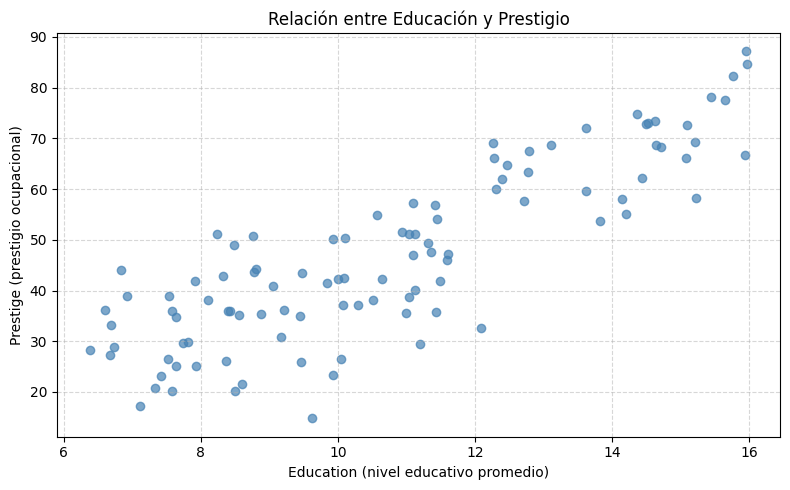

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['education'], df['prestige'], color='steelblue', alpha=0.7)
plt.xlabel('Education (nivel educativo promedio)')
plt.ylabel('Prestige (prestigio ocupacional)')
plt.title('Relación entre Educación y Prestigio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

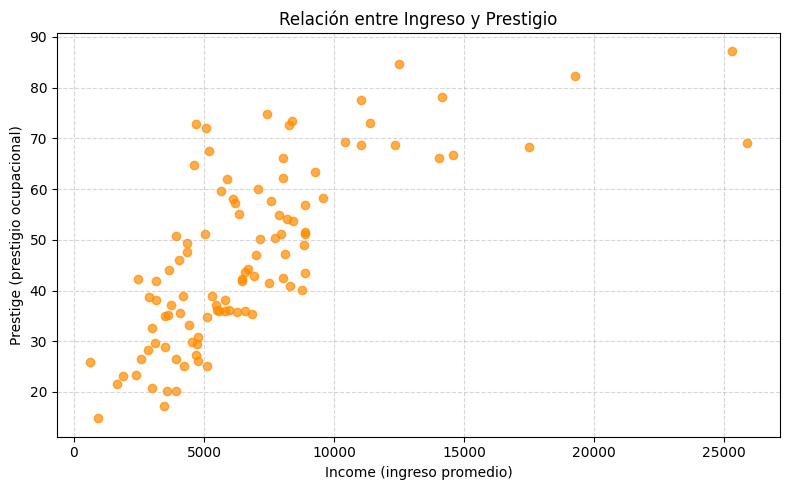

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df['income'], df['prestige'], color='darkorange', alpha=0.7)
plt.xlabel('Income (ingreso promedio)')
plt.ylabel('Prestige (prestigio ocupacional)')
plt.title('Relación entre Ingreso y Prestigio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

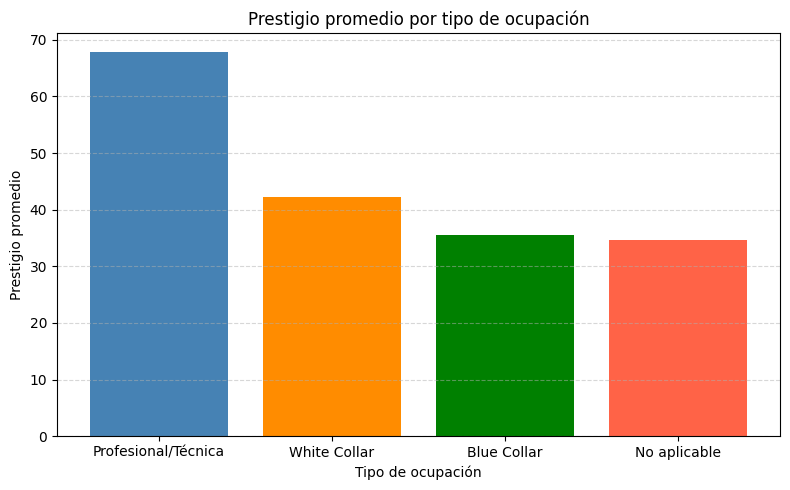

In [28]:
# Mapear los valores numéricos a etiquetas descriptivas
tipo_labels = {0: 'No aplicable', 1: 'Profesional/Técnica', 2: 'Blue Collar', 3: 'White Collar'}
df['type_label'] = df['type_num'].map(tipo_labels)

prestige_por_tipo = df.groupby('type_label')['prestige'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(prestige_por_tipo.index, prestige_por_tipo.values, color=['steelblue','darkorange','green','tomato'])
plt.xlabel('Tipo de ocupación')
plt.ylabel('Prestigio promedio')
plt.title('Prestigio promedio por tipo de ocupación')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Seleccionar variables
columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print("Datos escalados correctamente.")
print(f"Shape para clustering: {X_escalado.shape}")

Datos escalados correctamente.
Shape para clustering: (102, 5)


In [30]:
# K-Means con 4 clústeres
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

print("=== CENTROIDES - MODELO K=4 ===")
print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

=== CENTROIDES - MODELO K=4 ===
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [31]:
# K-Means con 5 clústeres
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print("=== CENTROIDES - MODELO K=5 ===")
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

=== CENTROIDES - MODELO K=5 ===
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


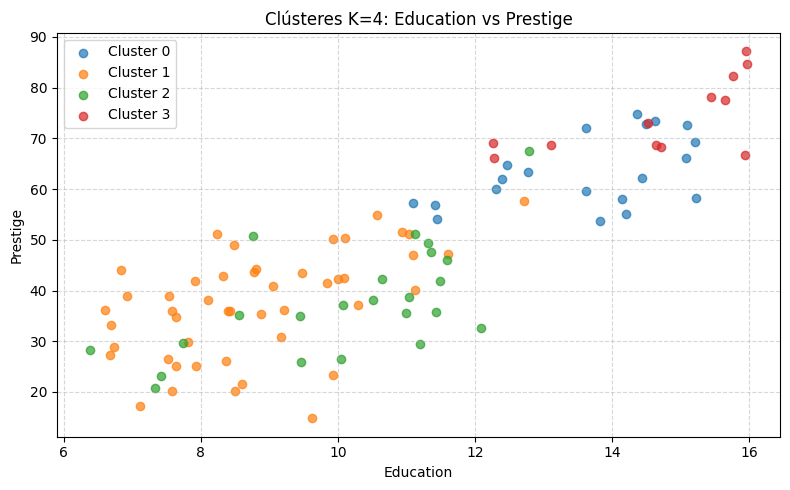

In [32]:
plt.figure(figsize=(8, 5))
for cluster in sorted(df['Cluster_4'].unique()):
    subset = df[df['Cluster_4'] == cluster]
    plt.scatter(subset['education'], subset['prestige'], label=f'Cluster {cluster}', alpha=0.7)

plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Clústeres K=4: Education vs Prestige')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

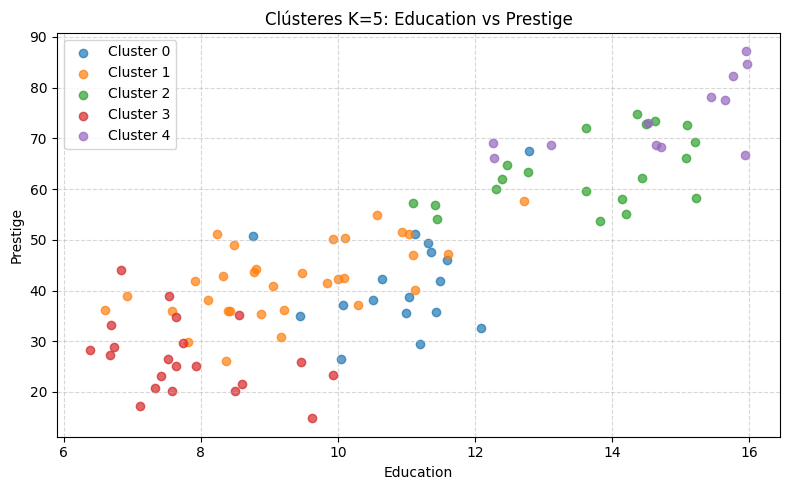

In [33]:
plt.figure(figsize=(8, 5))
for cluster in sorted(df['Cluster_5'].unique()):
    subset = df[df['Cluster_5'] == cluster]
    plt.scatter(subset['education'], subset['prestige'], label=f'Cluster {cluster}', alpha=0.7)

plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Clústeres K=5: Education vs Prestige')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()